# Project Akhir Data Wrangling

Raka Septyo Ifwiansyah (1314623001) UNJ Statistika 2023 A

1. Ide Project:
    
    a. Judul project:
    
    Data Wrangling Untuk Analisis Perilaku Konsumen Brazil Terhadap Produk Yang Diperjualbelikan Di Perbelanjaan Daring Olist
    
    b. Latar belakang, manfaat, dan tujuan beserta referensinya
    
    Mengetahui mengapa pelanggan membeli untuk mendapatkan wawasan (insight) mendalam tentang pelanggan guna mengambil keputusan bisnis yang lebih tepat sasaran dan efektif.

    Latar Belakang


*   Industri E-Commerce di Brazil memiliki tantangan unik mengingat luas wilayah geografis yang besar dan ketimpangan ekonomi antar negara bagian. Olist, sebagai salah satu platform e-commerce terbesar, menghubungkan penjual kecil dengan pembeli di seluruh negeri. Namun, kepuasan pelanggan seringkali dipengaruhi oleh faktor eksternal di luar kendali produk itu sendiri, seperti infrastruktur logistik dan daya beli ekonomi daerah.
Proyek ini dilatarbelakangi oleh kebutuhan untuk memahami bagaimana variabel makro (seperti GDP daerah) dan kinerja logistik (durasi pengiriman) berinteraksi dalam membentuk persepsi dan kepuasan pelanggan. Data mentah yang tersebar di berbagai sumber (transaksi internal, data pemerintah, dan kalender nasional) memerlukan proses Data Wrangling yang komprehensif sebelum dapat dianalisis.


    
    C Sumber data yang digunakan berasal dari minimal 3 sumber


-    Data Internal: Brazilian E-Commerce Public Dataset by Olist (Sumber: Kaggle) Ini adalah data utama yang memuat seluruh aktivitas transaksi dan umpan balik pelanggan. order_id: ID unik untuk setiap transaksi. Ini adalah "kunci utama" untuk menghubungkan detail barang dan ulasan. customer_state: Lokasi negara bagian pembeli (contoh: SP, RJ, MG). Digunakan untuk analisis geografis dan penghubung ke data GDP. order_purchase_timestamp: Waktu pembelian. Digunakan untuk melihat tren penjualan (harian/bulanan) dan menghubungkan ke data Hari Libur. price & freight_value: Harga barang dan ongkos kirim. Digunakan untuk analisis nilai transaksi (Monetary) dan korelasi dengan jarak/ekonomi. review_score: Rating bintang (1-5). Variabel krusial untuk mengukur kepuasan pelanggan (Customer Satisfaction).
-  Data Eksternal 1: Regional Account of Brazil (GDP by State)
(Sumber: IBGE - Pemerintah Brazil) Ini adalah data makro-ekonomi untuk memberikan konteks pada lokasi pelanggan.
State (UF): Kode negara bagian (contoh: SP, RJ). Kolom ini di-join dengan customer_state dari dataset Olist.
GDP (PIB): Nilai Produk Domestik Bruto daerah tersebut.
Kuartil_GDP: (Fitur hasil olahan) Pengelompokan provinsi menjadi kategori "High GDP", "Medium GDP", dan "Low GDP" untuk melihat perbedaan daya beli antar wilayah.
-  Data Eksternal 2: Python Holidays Library (Brazil)
(Sumber: Python Library) Ini adalah data kalender untuk menganalisis faktor musiman (Seasonality).
Date: Tanggal merah. Kolom ini di-join dengan tanggal pada order_purchase_timestamp.
holiday_name: Nama hari libur (contoh: Christmas, Independence Day, Carnival).
is_holiday: (Fitur hasil olahan) Penanda biner (1 = Libur, 0 = Hari Biasa) untuk membandingkan apakah orang berbelanja lebih boros/hemat saat tanggal merah.


2. Proses Wrangling:
    
    a. Teknik pengambilan dan integrasi data
    
    b. Data cleaning
    
    c. Data eksplorasi
    
    d. Data publishing (raw data, hasil proses wrangling, dan dokumentasi
    
    pipeline)

In [ ]:
import pandas as pd

pd.set_option('display.max_columns', None)

# a. Teknik pengambilan dan integrasi data

## 1. Pengambilan dan membaca data

### Mengambil dan membaca:

1.   olist_orders
2.   olist_customers
3.   olist_order_items
4.   olist_products
5.   product_category_name_translation
6.   olist_order_reviews

In [ ]:
import gdown
import pandas as pd

file_id_olist_orders = "1mUu-V7HojZISsdgFtO4AsckG5aXQkmqU"
url_id_olist_orders = f"https://drive.google.com/uc?export=download&id={file_id_olist_orders}"
olist_orders = "olist_orders.csv"

gdown.download(url_id_olist_orders, olist_orders, quiet=False)

df_olist_orders = pd.read_csv(olist_orders)
print(df_olist_orders.head())
print(df_olist_orders.shape)

Downloading...
From: https://drive.google.com/uc?export=download&id=1mUu-V7HojZISsdgFtO4AsckG5aXQkmqU
To: /content/olist_orders.csv
100%|██████████| 17.7M/17.7M [00:01<00:00, 14.1MB/s]


                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

In [ ]:
import gdown
import pandas as pd

file_id_olist_customers = "1jJdnbjMjeJwWXo-UiFjDNvM_NcYcgYRe"
url_id_olist_customers = f"https://drive.google.com/uc?export=download&id={file_id_olist_customers}"
olist_customers = "olist_customers.csv"

gdown.download(url_id_olist_customers, olist_customers, quiet=False)

df_olist_customers = pd.read_csv(olist_customers)
print(df_olist_customers.head())
print(df_olist_customers.shape)

Downloading...
From: https://drive.google.com/uc?export=download&id=1jJdnbjMjeJwWXo-UiFjDNvM_NcYcgYRe
To: /content/olist_customers.csv
100%|██████████| 9.03M/9.03M [00:00<00:00, 23.1MB/s]


                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
(99441, 5)


In [ ]:
import gdown
import pandas as pd

file_id_olist_order_items = "1dfO3UsE_AY8NFuhXl8k1WLnX-kWNauLq"
url_id_olist_order_items = f"https://drive.google.com/uc?export=download&id={file_id_olist_order_items}"
olist_order_items = "olist_order_items.csv"

gdown.download(url_id_olist_order_items, olist_order_items, quiet=False)

df_olist_order_items = pd.read_csv(olist_order_items)
print(df_olist_order_items.head())
print(df_olist_order_items.shape)

Downloading...
From: https://drive.google.com/uc?export=download&id=1dfO3UsE_AY8NFuhXl8k1WLnX-kWNauLq
To: /content/olist_order_items.csv
100%|██████████| 15.4M/15.4M [00:00<00:00, 21.1MB/s]


                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   
3  00024acbcdf0a6daa1e931b038114c75              1   
4  00042b26cf59d7ce69dfabb4e55b4fd9              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   
3  7634da152a4610f1595efa32f14722fc  9d7a1d34a5052409006425275ba1c2b4   
4  ac6c3623068f30de03045865e4e10089  df560393f3a51e74553ab94004ba5c87   

   shipping_limit_date   price  freight_value  
0  2017-09-19 09:45:35   58.90          13.29  
1  2017-05-03 11:05:13  239.90          19.93  
2  2018-01-18 14:48:30  199.00          17.87  
3  2018-08-15 10:10:18   12.99          12.7

In [ ]:
import gdown
import pandas as pd

file_id_olist_products = "1HeiPX6TZlX9nA0IMmX9MH09n7ECMCGCP"
url_id_olist_products = f"https://drive.google.com/uc?export=download&id={file_id_olist_products}"
olist_products = "olist_products.csv"

gdown.download(url_id_olist_products, olist_products, quiet=False)

df_olist_products = pd.read_csv(olist_products)
print(df_olist_products.head())
print(df_olist_products.shape)

Downloading...
From: https://drive.google.com/uc?export=download&id=1HeiPX6TZlX9nA0IMmX9MH09n7ECMCGCP
To: /content/olist_products.csv
100%|██████████| 2.38M/2.38M [00:00<00:00, 166MB/s]

                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  
0             225.0               16.0               10.0              14.0  
1            1000.0       

In [ ]:
import gdown
import pandas as pd

file_id_product_category_name_translation = "1rkwocRU7uuO-u1OaQgCtfP-PBHRBCuHR"
url_id_product_category_name_translation = f"https://drive.google.com/uc?export=download&id={file_id_product_category_name_translation}"
product_category_name_translation = "product_category_name_translation.csv"

gdown.download(url_id_product_category_name_translation, product_category_name_translation, quiet=False)

df_product_category_name_translation = pd.read_csv(product_category_name_translation)
print(df_product_category_name_translation.head())
print(df_product_category_name_translation.shape)

Downloading...
From: https://drive.google.com/uc?export=download&id=1rkwocRU7uuO-u1OaQgCtfP-PBHRBCuHR
To: /content/product_category_name_translation.csv
100%|██████████| 2.61k/2.61k [00:00<00:00, 8.68MB/s]

    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor
(71, 2)


In [ ]:
import gdown
import pandas as pd

file_id_olist_order_reviews = "1X8-4q81lpnlaI7pSXlQNdN8sCO7PSY6D"
url_id_olist_order_reviews = f"https://drive.google.com/uc?export=download&id={file_id_olist_order_reviews}"
olist_order_reviews = "olist_order_reviews.csv"

gdown.download(url_id_olist_order_reviews, olist_order_reviews, quiet=False)

df_olist_order_reviews = pd.read_csv(olist_order_reviews)
print(df_olist_order_reviews.head())
print(df_olist_order_reviews.shape)

Downloading...
From: https://drive.google.com/uc?export=download&id=1X8-4q81lpnlaI7pSXlQNdN8sCO7PSY6D
To: /content/olist_order_reviews.csv
100%|██████████| 14.5M/14.5M [00:00<00:00, 21.2MB/s]


                          review_id                          order_id  \
0  7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1  80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2  228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3  e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4  f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   

   review_score review_comment_title  \
0             4                  NaN   
1             5                  NaN   
2             5                  NaN   
3             5                  NaN   
4             5                  NaN   

                              review_comment_message review_creation_date  \
0                                                NaN  2018-01-18 00:00:00   
1                                                NaN  2018-03-10 00:00:00   
2                                                NaN  2018-02-17 00:00:00   
3           

### Mengambil, membaca:

1.   pib_otica_da_renda

### dan membuat:

2.   df_brazil_gdp_by_state_2017_2018

In [ ]:
import gdown
import pandas as pd

file_id_pib_otica_da_renda = "1-FKstftWwEADTHo0Um4yeSkcbu4vBupt"
url_id_pib_otica_da_renda = f"https://drive.google.com/uc?export=download&id={file_id_pib_otica_da_renda}"
pib_otica_da_renda = "pib_otica_da_renda.xlsx"

gdown.download(url_id_pib_otica_da_renda, pib_otica_da_renda, quiet=False)

df_pib_otica_da_renda = pd.read_excel(pib_otica_da_renda, sheet_name=None, header=None)
print(df_pib_otica_da_renda)

Downloading...
From: https://drive.google.com/uc?export=download&id=1-FKstftWwEADTHo0Um4yeSkcbu4vBupt
To: /content/pib_otica_da_renda.xlsx
100%|██████████| 363k/363k [00:00<00:00, 78.3MB/s]


{'Sumário':                                                     0
0                                                 NaN
1   Sumário Tabela 1 - Produto Interno Bruto pela ...
2                                                 NaN
3                                     Tabela 1 Brasil
4                              Tabela 2  Região Norte
5                                  Tabela 3  Rondônia
6                                      Tabela 4  Acre
7                                  Tabela 5  Amazonas
8                                   Tabela 6  Roraima
9                                      Tabela 7  Pará
10                                    Tabela 8  Amapá
11                                Tabela 9  Tocantins
12                         Tabela 10  Região Nordeste
13                                Tabela 11  Maranhão
14                                   Tabela 12  Piauí
15                                   Tabela 13  Ceará
16                     Tabela 14  Rio Grande do Norte
17              

In [ ]:
import gdown
import pandas as pd

state_codes_directory = {
    'Rondônia': 'RO', 'Acre': 'AC', 'Amazonas': 'AM', 'Roraima': 'RR',
    'Pará': 'PA', 'Amapá': 'AP', 'Tocantins': 'TO', 'Maranhão': 'MA',
    'Piauí': 'PI', 'Ceará': 'CE', 'Rio Grande do Norte': 'RN', 'Paraíba': 'PB',
    'Pernambuco': 'PE', 'Alagoas': 'AL', 'Sergipe': 'SE', 'Bahia': 'BA',
    'Minas Gerais': 'MG', 'Espírito Santo': 'ES', 'Rio de Janeiro': 'RJ',
    'São Paulo': 'SP', 'Paraná': 'PR', 'Santa Catarina': 'SC',
    'Rio Grande do Sul': 'RS', 'Mato Grosso do Sul': 'MS', 'Mato Grosso': 'MT',
    'Goiás': 'GO', 'Distrito Federal': 'DF'
}

brazil_gdp_by_state_2017_2018 = []

for sheet_name, df in df_pib_otica_da_renda.items():
    try:
        state = str(df.iloc[6, 0])

        state_code = None
        for states, states_code in state_codes_directory.items():
            if states in state:
                state_code = states_code
                break

        if state_code:

            i19_cell = df.iloc[18, 8]
            j19_cell = df.iloc[18, 9]

            brazil_gdp_by_state_2017_2018.append({
                'customer_state': state_code,
                'GDP_2017': i19_cell,
                'GDP_2018': j19_cell
            })
            print(f"Sukses {state_code}: A7='{states}', Data={i19_cell}")

    except Exception:
        continue

df_brazil_gdp_by_state_2017_2018 = pd.DataFrame(brazil_gdp_by_state_2017_2018)

print(df_brazil_gdp_by_state_2017_2018.head())
print(f"Total Provinsi Terambil: {len(df_brazil_gdp_by_state_2017_2018)} (Target: 27)")

df_brazil_gdp_by_state_2017_2018.to_csv('gdp_brazil_by_state_2017_2018.csv', index=False)

Sukses RO: A7='Rondônia', Data=43516.14749002116
Sukses AC: A7='Acre', Data=14272.940593128029
Sukses AM: A7='Amazonas', Data=93240.19092026833
Sukses RR: A7='Roraima', Data=12104.70914653834
Sukses PA: A7='Pará', Data=155232.40379991897
Sukses AP: A7='Amapá', Data=15481.90832491075
Sukses TO: A7='Tocantins', Data=34108.13198695243
Sukses MA: A7='Maranhão', Data=89542.75730249175
Sukses PI: A7='Piauí', Data=45365.54102402908
Sukses CE: A7='Ceará', Data=147921.53398322707
Sukses RN: A7='Rio Grande do Norte', Data=64305.99505517344
Sukses PB: A7='Paraíba', Data=62396.77552487873
Sukses PE: A7='Pernambuco', Data=181609.50084217289
Sukses AL: A7='Alagoas', Data=52851.06693594546
Sukses SE: A7='Sergipe', Data=40711.48616306332
Sukses BA: A7='Bahia', Data=268724.09022701735
Sukses MG: A7='Minas Gerais', Data=576375.5446827656
Sukses ES: A7='Espírito Santo', Data=113399.93679153567
Sukses RJ: A7='Rio de Janeiro', Data=671605.668053873
Sukses SP: A7='São Paulo', Data=2120761.6351115643
Sukses 

### Mengambil:
1.   brazil_holidays_2017_2018
### dan membuat:
2.   df_brazil_holidays_2017_2018

In [ ]:
!pip install holidays

import pandas as pd
import holidays

brazil_holidays = holidays.BR(years=[2017, 2018])

# Ubah jadi Tabel (DataFrame)
brazil_holiday_2017_2018 = []
for date, name in brazil_holidays.items():
    brazil_holiday_2017_2018.append({
        'date': str(date),
        'holiday_name': name
    })

df_brazil_holidays_2017_2018 = pd.DataFrame(brazil_holiday_2017_2018)
df_brazil_holidays_2017_2018['date'] = pd.to_datetime(df_brazil_holidays_2017_2018['date'])

print(df_brazil_holidays_2017_2018)

         date                  holiday_name
0  2017-01-01  Universal Fraternization Day
1  2017-04-14                   Good Friday
2  2017-04-21               Tiradentes' Day
3  2017-05-01                  Worker's Day
4  2017-09-07              Independence Day
5  2017-10-12         Our Lady of Aparecida
6  2017-11-02                All Souls' Day
7  2017-11-15     Republic Proclamation Day
8  2017-12-25                 Christmas Day
9  2018-01-01  Universal Fraternization Day
10 2018-03-30                   Good Friday
11 2018-04-21               Tiradentes' Day
12 2018-05-01                  Worker's Day
13 2018-09-07              Independence Day
14 2018-10-12         Our Lady of Aparecida
15 2018-11-02                All Souls' Day
16 2018-11-15     Republic Proclamation Day
17 2018-12-25                 Christmas Day


In [ ]:
from google.colab import files
df_brazil_holidays_2017_2018.csv = 'df_brazil_holidays_2017_2018.csv'

df_brazil_holidays_2017_2018.to_csv(df_brazil_holidays_2017_2018.csv, index=False)

try:
    files.download(df_brazil_holidays_2017_2018.csv)
except Exception as e:
    print(f"Gagal download: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 2. Integrasi Data

### Menggabungkan:
1.   olist_orders
2.   olist_customers
3.   olist_order_items
4.   olist_products
5.   product_category_name_translation
6.   olist_order_reviews

### dan membuat:
1.   df_olist

In [ ]:
#- 1 = olist_orders_dataset.csv & olist_customers_dataset.csv Kunci: customer_id
#- 2 = 1 & olist_order_items_dataset.csv Kunci: order_id
#- 3 = 2 & olist_products_dataset.csv Kunci: product_id
#- 4 = 3 & product_category_name_translation.csv Kunci: product_category_name
#- 5 = 4 & olist_order_reviews_dataset.csv Kunci: order_id.

In [ ]:
merge_df_1 = pd.merge(df_olist_orders, df_olist_customers, on='customer_id', how='inner').drop_duplicates()
merge_df_1

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


In [ ]:
merge_df_2 = pd.merge(merge_df_1, df_olist_order_items, on='order_id', how='inner').drop_duplicates()
merge_df_2

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10
112646,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02
112647,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59
112648,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59


In [ ]:
merge_df_3 = pd.merge(merge_df_2, df_olist_products, on='product_id', how='inner').drop_duplicates()
merge_df_3

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,...,174.90,20.10,bebes,52.0,828.0,4.0,4950.0,40.0,10.0,40.0
112646,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,...,205.99,65.02,eletrodomesticos_2,51.0,500.0,2.0,13300.0,32.0,90.0,22.0
112647,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,179.99,40.59,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0
112648,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,179.99,40.59,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0


In [ ]:
merge_df_4 = pd.merge(merge_df_3, df_product_category_name_translation, on='product_category_name', how='inner').drop_duplicates()
merge_df_4

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111018,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,...,20.10,bebes,52.0,828.0,4.0,4950.0,40.0,10.0,40.0,baby
111019,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,...,65.02,eletrodomesticos_2,51.0,500.0,2.0,13300.0,32.0,90.0,22.0,home_appliances_2
111020,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,40.59,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,computers_accessories
111021,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,40.59,informatica_acessorios,59.0,1893.0,1.0,6550.0,20.0,20.0,20.0,computers_accessories


In [ ]:
df_olist = pd.merge(merge_df_4, df_olist_order_reviews, on='order_id', how='inner').drop_duplicates()
df_olist

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,perfumery,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,auto,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,30.0,10.0,20.0,pet_shop,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,51.0,15.0,15.0,stationery,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110745,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,...,40.0,10.0,40.0,baby,29bb71b2760d0f876dfa178a76bc4734,4,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01
110746,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,...,32.0,90.0,22.0,home_appliances_2,371579771219f6db2d830d50805977bb,5,NaN,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57
110747,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,20.0,20.0,20.0,computers_accessories,8ab6855b9fe9b812cd03a480a25058a1,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56
110748,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,20.0,20.0,20.0,computers_accessories,8ab6855b9fe9b812cd03a480a25058a1,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56


### Membuat:
1.   df_olistdf_order_purchase_timestamp_dt_normalized
2.   df_brazil_holidays_2017_2018_rename

In [ ]:
order_purchase_timestamp_dt = pd.to_datetime(df_olist['order_purchase_timestamp'])
order_purchase_timestamp_dt_normalized = order_purchase_timestamp_dt.dt.normalize()
df_order_purchase_timestamp_dt_normalized = order_purchase_timestamp_dt_normalized.to_frame(name='order_purchase_timestamp')
df_order_purchase_timestamp_dt_normalized

,order_purchase_timestamp
0,2017-10-02
1,2018-07-24
2,2018-08-08
3,2017-11-18
4,2018-02-13
...,...
110745,2018-02-06
110746,2017-08-27
110747,2018-01-08
110748,2018-01-08


In [ ]:
df_brazil_holidays_2017_2018_rename = df_brazil_holidays_2017_2018.rename(columns={'date':'df_order_purchase_timestamp_dt_normalized'})
df_brazil_holidays_2017_2018_rename

,df_order_purchase_timestamp_dt_normalized,holiday_name
0,2017-01-01,Universal Fraternization Day
1,2017-04-14,Good Friday
2,2017-04-21,Tiradentes' Day
3,2017-05-01,Worker's Day
4,2017-09-07,Independence Day
5,2017-10-12,Our Lady of Aparecida
6,2017-11-02,All Souls' Day
7,2017-11-15,Republic Proclamation Day
8,2017-12-25,Christmas Day
9,2018-01-01,Universal Fraternization Day


### Menggabungkan:
1.   df_olist
2.   df_brazil_gdp_by_state_2017_2018
### dan membuat:
1.   df_olist_brazil_gdp_by_state_2017_2018
2.   df_olist_brazil_gdp_by_state_2017_2018_inserted

In [ ]:
df_olist_brazil_gdp_by_state_2017_2018 = pd.merge(df_olist, df_brazil_gdp_by_state_2017_2018, on='customer_state', how='inner').drop_duplicates()
df_olist_brazil_gdp_by_state_2017_2018

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_width_cm,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,GDP_2017,GDP_2018
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,2.120762e+06,2.210562e+06
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,19.0,perfumery,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,2.687241e+05,2.862395e+05
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,21.0,auto,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,1.919483e+05,1.956817e+05
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,20.0,pet_shop,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,6.430600e+04,6.696956e+04
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,15.0,stationery,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,2.120762e+06,2.210562e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110745,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,...,40.0,baby,29bb71b2760d0f876dfa178a76bc4734,4,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01,2.120762e+06,2.210562e+06
110746,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,...,22.0,home_appliances_2,371579771219f6db2d830d50805977bb,5,NaN,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57,2.687241e+05,2.862395e+05
110747,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,20.0,computers_accessories,8ab6855b9fe9b812cd03a480a25058a1,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,6.716057e+05,7.588590e+05
110748,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,20.0,computers_accessories,8ab6855b9fe9b812cd03a480a25058a1,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,6.716057e+05,7.588590e+05


In [ ]:
# RUN SEKALI SAJA, JIKA SUDAH RUN LEBIH DARI SEKALI AKAN ERROR, KARENA KOLOM BARU SUDAH DIINSERT,
# RUN LEBIH DARI SEKALI HANYA AKAN MENGINSERT KOLOM YANG SUDA ADA SEHINGGA AKAN ERROR

df_olist_brazil_gdp_by_state_2017_2018_inserted = df_olist_brazil_gdp_by_state_2017_2018.copy()
df_olist_brazil_gdp_by_state_2017_2018_inserted.insert(3, 'df_order_purchase_timestamp_dt_normalized', df_order_purchase_timestamp_dt_normalized['order_purchase_timestamp'].values)

In [ ]:
df_olist_brazil_gdp_by_state_2017_2018_inserted

,order_id,customer_id,order_status,df_order_purchase_timestamp_dt_normalized,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,...,product_width_cm,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,GDP_2017,GDP_2018
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,...,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,2.120762e+06,2.210562e+06
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,...,19.0,perfumery,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,2.687241e+05,2.862395e+05
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,...,21.0,auto,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,1.919483e+05,1.956817e+05
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,...,20.0,pet_shop,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,6.430600e+04,6.696956e+04
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,...,15.0,stationery,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,2.120762e+06,2.210562e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110745,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,...,40.0,baby,29bb71b2760d0f876dfa178a76bc4734,4,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01,2.120762e+06,2.210562e+06
110746,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,...,22.0,home_appliances_2,371579771219f6db2d830d50805977bb,5,NaN,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57,2.687241e+05,2.862395e+05
110747,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,...,20.0,computers_accessories,8ab6855b9fe9b812cd03a480a25058a1,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,6.716057e+05,7.588590e+05
110748,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,...,20.0,computers_accessories,8ab6855b9fe9b812cd03a480a25058a1,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,6.716057e+05,7.588590e+05


### Menggabungkan:
1.   df_olist_brazil_gdp_by_state_2017_2018_inserted
2.   df_brazil_holidays_2017_2018_rename
### dan membuat:
1.   df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename

In [ ]:
df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename = pd.merge(df_olist_brazil_gdp_by_state_2017_2018_inserted, df_brazil_holidays_2017_2018_rename, on='df_order_purchase_timestamp_dt_normalized', how='left').drop_duplicates()
df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename

,order_id,customer_id,order_status,df_order_purchase_timestamp_dt_normalized,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,...,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,GDP_2017,GDP_2018,holiday_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,...,housewares,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,2.120762e+06,2.210562e+06,NaN
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,...,perfumery,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,2.687241e+05,2.862395e+05,NaN
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,...,auto,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,1.919483e+05,1.956817e+05,NaN
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,...,pet_shop,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,6.430600e+04,6.696956e+04,NaN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,...,stationery,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,2.120762e+06,2.210562e+06,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110745,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,...,baby,29bb71b2760d0f876dfa178a76bc4734,4,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01,2.120762e+06,2.210562e+06,NaN
110746,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,...,home_appliances_2,371579771219f6db2d830d50805977bb,5,NaN,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57,2.687241e+05,2.862395e+05,NaN
110747,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,...,computers_accessories,8ab6855b9fe9b812cd03a480a25058a1,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,6.716057e+05,7.588590e+05,NaN
110748,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,...,computers_accessories,8ab6855b9fe9b812cd03a480a25058a1,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,6.716057e+05,7.588590e+05,NaN


In [ ]:
holiday_name_replace = df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename.pop('GDP_2018')

df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename.insert(14, 'GDP_2018', holiday_name_replace)

df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename

,order_id,customer_id,order_status,df_order_purchase_timestamp_dt_normalized,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,...,product_width_cm,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,GDP_2017,holiday_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,...,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,2.120762e+06,NaN
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,...,19.0,perfumery,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,2.687241e+05,NaN
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,...,21.0,auto,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,1.919483e+05,NaN
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,...,20.0,pet_shop,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,6.430600e+04,NaN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,...,15.0,stationery,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,2.120762e+06,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110745,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,...,40.0,baby,29bb71b2760d0f876dfa178a76bc4734,4,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01,2.120762e+06,NaN
110746,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,...,22.0,home_appliances_2,371579771219f6db2d830d50805977bb,5,NaN,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57,2.687241e+05,NaN
110747,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,...,20.0,computers_accessories,8ab6855b9fe9b812cd03a480a25058a1,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,6.716057e+05,NaN
110748,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,...,20.0,computers_accessories,8ab6855b9fe9b812cd03a480a25058a1,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,6.716057e+05,NaN


In [ ]:
holiday_name_replace = df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename.pop('GDP_2017')

df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename.insert(14, 'GDP_2017', holiday_name_replace)

df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename

,order_id,customer_id,order_status,df_order_purchase_timestamp_dt_normalized,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,...,product_height_cm,product_width_cm,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,holiday_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,...,8.0,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,NaN
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,...,13.0,19.0,perfumery,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,NaN
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,...,19.0,21.0,auto,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,NaN
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,...,10.0,20.0,pet_shop,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,NaN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,...,15.0,15.0,stationery,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110745,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,...,10.0,40.0,baby,29bb71b2760d0f876dfa178a76bc4734,4,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01,NaN
110746,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,...,90.0,22.0,home_appliances_2,371579771219f6db2d830d50805977bb,5,NaN,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57,NaN
110747,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,...,20.0,20.0,computers_accessories,8ab6855b9fe9b812cd03a480a25058a1,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,NaN
110748,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,...,20.0,20.0,computers_accessories,8ab6855b9fe9b812cd03a480a25058a1,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56,NaN


In [ ]:
holiday_name_replace = df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename.pop('holiday_name')

df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename.insert(3, 'holiday_name', holiday_name_replace)

df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename

,order_id,customer_id,order_status,holiday_name,df_order_purchase_timestamp_dt_normalized,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,...,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,NaN,2017-10-02,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,...,19.0,8.0,13.0,housewares,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,NaN,2018-07-24,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,...,19.0,13.0,19.0,perfumery,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,NaN,2018-08-08,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,...,24.0,19.0,21.0,auto,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,NaN,2017-11-18,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,...,30.0,10.0,20.0,pet_shop,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,NaN,2018-02-13,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,...,51.0,15.0,15.0,stationery,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110745,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,NaN,2018-02-06,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,...,40.0,10.0,40.0,baby,29bb71b2760d0f876dfa178a76bc4734,4,NaN,So uma peça que veio rachado mas tudo bem rs,2018-03-01 00:00:00,2018-03-02 17:50:01
110746,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,NaN,2017-08-27,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,...,32.0,90.0,22.0,home_appliances_2,371579771219f6db2d830d50805977bb,5,NaN,Foi entregue antes do prazo.,2017-09-22 00:00:00,2017-09-22 23:10:57
110747,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,NaN,2018-01-08,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,...,20.0,20.0,20.0,computers_accessories,8ab6855b9fe9b812cd03a480a25058a1,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56
110748,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,NaN,2018-01-08,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,...,20.0,20.0,20.0,computers_accessories,8ab6855b9fe9b812cd03a480a25058a1,2,NaN,Foi entregue somente 1. Quero saber do outro p...,2018-01-26 00:00:00,2018-01-27 09:16:56


In [ ]:
import pandas as pd

df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename['order_purchase_timestamp'] = pd.to_datetime(df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename['order_purchase_timestamp'])

df_before_integrated = df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename[df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename['order_purchase_timestamp'].dt.year.isin([2017, 2018])].copy()

df_before_integrated.reset_index(drop=True, inplace=True)

print(f"Jumlah baris Awal (Termasuk 2016): {len(df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename)}")
print(f"Jumlah baris Akhir (Cuma 2017-18): {len(df_before_integrated)}")
print("Distribusi Tahun di Data Baru:")
print(df_before_integrated['order_purchase_timestamp'].dt.year.value_counts().sort_index())

Jumlah baris Awal (Termasuk 2016): 110750
Jumlah baris Akhir (Cuma 2017-18): 110384
Distribusi Tahun di Data Baru:
order_purchase_timestamp
2017    49873
2018    60511
Name: count, dtype: int64


In [ ]:
tahun_tersisa = df_before_integrated['order_purchase_timestamp'].dt.year.unique()

print("Tahun yang ada di data sekarang:")
print(tahun_tersisa)

Tahun yang ada di data sekarang:
[2017 2018]


In [ ]:
df_olist_raw_integrated = df_before_integrated

- Pindahin kolom gdp di ujung kanan, pikirin kasih indikator gdp rendah/tinggi

# b. Data cleaning

In [ ]:
cleaning_df_olist = df_olist_raw_integrated.copy()

## 1. Correct Errors

In [ ]:
import pandas as pd

print("--- [1] HANDLING DUPLICATES ---")

jumlah_duplikat = cleaning_df_olist.duplicated().sum()
print(f"Jumlah baris duplikat ditemukan: {jumlah_duplikat}")

if jumlah_duplikat > 0:
    cleaning_df_olist.drop_duplicates(inplace=True)
    print(" Duplikat berhasil dihapus.")
else:
    print(" Data aman (Tidak ada duplikat).")

print("\n--- [2] CORRECT ERRORS ---")

def fix_portuguese_errors(text):
    if pd.isnull(text): return text
    text = str(text)
    replacements = {
        'Ã§': 'ç', 'Ã£': 'ã', 'Ã©': 'é', 'Ã¡': 'á',
        'Ã³': 'ó', 'Ãª': 'ê', 'Ã': 'í', 'Ã½': 'ú'
    }
    for bad, good in replacements.items():
        text = text.replace(bad, good)
    return text

cleaning_df_olist['review_comment_message'] = cleaning_df_olist['review_comment_message'].apply(fix_portuguese_errors)
cleaning_df_olist['review_comment_title'] = cleaning_df_olist['review_comment_title'].apply(fix_portuguese_errors)

cleaning_df_olist.rename(columns={
    'product_name_lenght': 'product_name_length',
    'product_description_lenght': 'product_description_length'
}, inplace=True)

print(cleaning_df_olist[['review_comment_message', 'product_name_length']].head())

--- [1] HANDLING DUPLICATES ---
Jumlah baris duplikat ditemukan: 0
 Data aman (Tidak ada duplikat).

--- [2] CORRECT ERRORS ---
                              review_comment_message  product_name_length
0  Não testei o produto ainda, mas ele veio corre...                 40.0
1                               Muito bom o produto.                 29.0
2                                                NaN                 46.0
3  O produto foi exatamente o que eu esperava e e...                 59.0
4                                                NaN                 38.0



## 2. Handle Missing Values

In [ ]:
cleaning_df_olist.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
holiday_name,108709
df_order_purchase_timestamp_dt_normalized,0
order_purchase_timestamp,0
order_approved_at,14
order_delivered_carrier_date,1108
order_delivered_customer_date,2248
order_estimated_delivery_date,0


In [ ]:
import pandas as pd

df_target = cleaning_df_olist.copy()

print(f"Jumlah baris awal: {len(df_target)}")

values_to_fill = {
    'holiday_name': 'Normal Day',
    'review_comment_title': 'No Title',
    'review_comment_message': 'No Comment'
}
df_target.fillna(value=values_to_fill, inplace=True)
print(" Imputasi Holiday & Review selesai.")


subset_produk = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
df_target.dropna(subset=subset_produk, inplace=True)

subset_logistik = ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']
df_target.dropna(subset=subset_logistik, inplace=True)

print(" Penghapusan baris data logistik yang tidak lengkap selesai.")

print(f"Jumlah baris akhir: {len(df_target)}")
print("\nSisa Missing Values:")
print(df_target.isnull().sum()[df_target.isnull().sum() > 0])

cleaning_df_olist = df_target

Jumlah baris awal: 110384
 Imputasi Holiday & Review selesai.
 Penghapusan baris data logistik yang tidak lengkap selesai.
Jumlah baris akhir: 108120

Sisa Missing Values:
Series([], dtype: int64)



## 3. Remove Irrelevant Information

In [ ]:
#df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename.info()
#df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename.isna().sum()
#df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename.describe()
df_olist_brazil_gdp_by_state_2017_2018_inserted_brazil_holidays_2017_2018_rename.columns

Index(['order_id', 'customer_id', 'order_status', 'holiday_name',
       'df_order_purchase_timestamp_dt_normalized', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'GDP_2017', 'GDP_2018', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'review_id', 'review_score',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp'],
      dtype='object')

In [ ]:
cleaning_df_olist_1 = cleaning_df_olist.sort_values(by='order_purchase_timestamp',ascending=True)
cleaning_df_olist_1 = cleaning_df_olist_1.reset_index(drop=True)
cleaning_df_olist_1

,order_id,customer_id,order_status,holiday_name,df_order_purchase_timestamp_dt_normalized,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,...,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,ec7a019261fce44180373d45b442d78f,c24fc5f9a446b4d8262041b9c64de772,delivered,Normal Day,2017-01-05,2017-01-05 11:56:06,2017-01-05 12:10:17,2017-01-06 12:43:41,2017-01-11 13:14:05,2017-02-01 00:00:00,...,16.0,2.0,11.0,fashion_bags_accessories,5f45d6aa32336fa26cbc254721c81880,5,No Title,Adorei o produto! Super recomendo o lojista. R...,2017-01-12 00:00:00,2017-01-13 20:22:46
1,b95a0a8bd30aece4e94e81f0591249d8,ff3c6d35b4927c9b965aa6a68dcf56e4,delivered,Normal Day,2017-01-05,2017-01-05 12:01:20,2017-01-07 03:35:37,2017-01-11 16:22:53,2017-01-17 15:38:58,2017-02-13 00:00:00,...,16.0,2.0,11.0,auto,4e9bc73d2795d85dc2e8b7dbb99e304c,5,No Title,"Adorei o produto, condiz com as imagens, a ent...",2017-01-18 00:00:00,2017-01-18 10:56:46
2,38bcb524e1c38c2c1b60600a80fc8999,d2c63ad286e3ca9dd69218008d61ff81,delivered,Normal Day,2017-01-05,2017-01-05 12:06:36,2017-01-07 03:45:22,2017-01-11 15:35:54,2017-01-16 16:05:22,2017-02-13 00:00:00,...,16.0,2.0,11.0,pet_shop,e48def6468ee7a31da5dc7249487304c,5,No Title,Loja entregou no prazo sem qualquer problema. ...,2017-01-17 00:00:00,2017-01-18 11:51:43
3,7a18a504c1a4b32d883e68de2e1a7db0,e6bee29442c761ff0dfb9a4414922a5c,delivered,Normal Day,2017-01-05,2017-01-05 12:09:08,2017-01-07 03:44:08,2017-01-11 15:35:53,2017-01-16 15:43:29,2017-02-13 00:00:00,...,16.0,2.0,11.0,pet_shop,ef0cb49c494b34d55782e4c91bdc8730,5,No Title,Adorei a embalagem e o atendimento. Produto ma...,2017-01-17 00:00:00,2017-01-18 11:54:40
4,6acecf438369055d9243e121045cca74,42d857e22f61f10476f0cda1aacc018a,delivered,Normal Day,2017-01-05,2017-01-05 12:11:23,2017-01-07 03:44:07,2017-01-11 16:22:53,2017-01-17 16:06:30,2017-02-13 00:00:00,...,16.0,2.0,11.0,pet_shop,ca514a4c482df7a74fa097aebd4af3de,5,No Title,"adorei o produto, a embalagem, o cuidado no en...",2017-01-18 00:00:00,2017-01-20 10:01:16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108115,0b223d92c27432930dfe407c6aea3041,e60df9449653a95af4549bbfcb18a6eb,delivered,Normal Day,2018-08-29,2018-08-29 14:18:23,2018-08-29 14:31:07,2018-08-29 15:29:00,2018-08-30 16:24:55,2018-09-04 00:00:00,...,48.0,49.0,49.0,kitchen_dining_laundry_garden_furniture,6c50d16eb583d5db7e841b77e89b7045,5,No Title,No Comment,2018-08-31 00:00:00,2018-10-24 16:27:36
108116,0b223d92c27432930dfe407c6aea3041,e60df9449653a95af4549bbfcb18a6eb,delivered,Normal Day,2018-08-29,2018-08-29 14:18:23,2018-08-29 14:31:07,2018-08-29 15:29:00,2018-08-30 16:24:55,2018-09-04 00:00:00,...,48.0,49.0,49.0,kitchen_dining_laundry_garden_furniture,6c50d16eb583d5db7e841b77e89b7045,5,No Title,No Comment,2018-08-31 00:00:00,2018-10-24 16:27:36
108117,168626408cb32af0ffaf76711caae1dc,6e353700bc7bcdf6ebc15d6de16d7002,delivered,Normal Day,2018-08-29,2018-08-29 14:18:28,2018-08-29 14:30:23,2018-08-29 18:51:00,2018-08-30 16:52:31,2018-09-11 00:00:00,...,31.0,16.0,28.0,health_beauty,39eae4e4d255222202c4255e8eee9084,5,Chegou rápido e correto,Recomendo,2018-08-31 00:00:00,2018-09-02 20:55:45
108118,03ef5dedbe7492bdae72eec50764c43f,496630b6740bcca28fce9ba50d8a26ef,delivered,Normal Day,2018-08-29,2018-08-29 14:52:00,2018-08-29 15:05:22,2018-08-29 20:01:00,2018-08-30 16:36:59,2018-09-03 00:00:00,...,28.0,9.0,19.0,party_supplies,8a8ebb5019795478156fa952acd050b1,3,Recomendo,No Comment,2018-08-31 00:00:00,2018-08-31 20:02:48


In [ ]:
not_used_columns = [
    'df_order_purchase_timestamp_dt_normalized', # Helper column
    'product_category_name', # Sudah ada English
    'product_name_lenght', 'product_description_lenght', 'product_photos_qty', # Metadata
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', # Dimensi fisik
    'order_approved_at', 'order_delivered_carrier_date', 'shipping_limit_date', # Logistik internal
    'review_creation_date', 'review_answer_timestamp', # Timestamp review
    'review_id', 'order_item_id' # ID teknis
]

cleaning_df_olist_2 = cleaning_df_olist_1.drop(columns=not_used_columns, errors='ignore')

print(f"Jumlah kolom sebelum: {cleaning_df_olist_1.shape[1]}")
print(f"Jumlah kolom sesudah: {cleaning_df_olist_2.shape[1]}")
cleaning_df_olist_2

Jumlah kolom sebelum: 37
Jumlah kolom sesudah: 23


,order_id,customer_id,order_status,holiday_name,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,...,product_id,seller_id,price,freight_value,product_name_length,product_description_length,product_category_name_english,review_score,review_comment_title,review_comment_message
0,ec7a019261fce44180373d45b442d78f,c24fc5f9a446b4d8262041b9c64de772,delivered,Normal Day,2017-01-05 11:56:06,2017-01-11 13:14:05,2017-02-01 00:00:00,f7b981e8a280e455ac3cbe0d5d171bd1,80030,curitiba,...,f5d8f4fbc70ca2a0038b9a0010ed5cb0,48efc9d94a9834137efd9ea76b065a38,10.90,8.72,64.0,1710.0,fashion_bags_accessories,5,No Title,Adorei o produto! Super recomendo o lojista. R...
1,b95a0a8bd30aece4e94e81f0591249d8,ff3c6d35b4927c9b965aa6a68dcf56e4,delivered,Normal Day,2017-01-05 12:01:20,2017-01-17 15:38:58,2017-02-13 00:00:00,83e7958a94bd7f74a9414d8782f87628,80030,curitiba,...,6c04a068e5ab37749c980c42a036b9e3,48efc9d94a9834137efd9ea76b065a38,10.90,8.72,52.0,1367.0,auto,5,No Title,"Adorei o produto, condiz com as imagens, a ent..."
2,38bcb524e1c38c2c1b60600a80fc8999,d2c63ad286e3ca9dd69218008d61ff81,delivered,Normal Day,2017-01-05 12:06:36,2017-01-16 16:05:22,2017-02-13 00:00:00,728e4a7d0db4845270091ded0923c71f,80540,curitiba,...,680cc8535be7cc69544238c1d6a83fe8,48efc9d94a9834137efd9ea76b065a38,2.90,8.72,48.0,1392.0,pet_shop,5,No Title,Loja entregou no prazo sem qualquer problema. ...
3,7a18a504c1a4b32d883e68de2e1a7db0,e6bee29442c761ff0dfb9a4414922a5c,delivered,Normal Day,2017-01-05 12:09:08,2017-01-16 15:43:29,2017-02-13 00:00:00,728e4a7d0db4845270091ded0923c71f,80540,curitiba,...,c0d4027067afcf9c1697cce981b8fed6,48efc9d94a9834137efd9ea76b065a38,7.90,8.72,63.0,1269.0,pet_shop,5,No Title,Adorei a embalagem e o atendimento. Produto ma...
4,6acecf438369055d9243e121045cca74,42d857e22f61f10476f0cda1aacc018a,delivered,Normal Day,2017-01-05 12:11:23,2017-01-17 16:06:30,2017-02-13 00:00:00,728e4a7d0db4845270091ded0923c71f,80540,curitiba,...,1514ddb0f4a5afc8d24104e89c714403,48efc9d94a9834137efd9ea76b065a38,9.90,8.72,54.0,282.0,pet_shop,5,No Title,"adorei o produto, a embalagem, o cuidado no en..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108115,0b223d92c27432930dfe407c6aea3041,e60df9449653a95af4549bbfcb18a6eb,delivered,Normal Day,2018-08-29 14:18:23,2018-08-30 16:24:55,2018-09-04 00:00:00,5c58de6fb80e93396e2f35642666b693,80045,curitiba,...,2b4472df15512a2825ae86fd9ae79335,67bf6941ba2f1fa1d02c375766bc3e53,209.00,46.48,44.0,112.0,kitchen_dining_laundry_garden_furniture,5,No Title,No Comment
108116,0b223d92c27432930dfe407c6aea3041,e60df9449653a95af4549bbfcb18a6eb,delivered,Normal Day,2018-08-29 14:18:23,2018-08-30 16:24:55,2018-09-04 00:00:00,5c58de6fb80e93396e2f35642666b693,80045,curitiba,...,2b4472df15512a2825ae86fd9ae79335,67bf6941ba2f1fa1d02c375766bc3e53,209.00,46.48,44.0,112.0,kitchen_dining_laundry_garden_furniture,5,No Title,No Comment
108117,168626408cb32af0ffaf76711caae1dc,6e353700bc7bcdf6ebc15d6de16d7002,delivered,Normal Day,2018-08-29 14:18:28,2018-08-30 16:52:31,2018-09-11 00:00:00,7febafa06d9d8f232a900a2937f04338,38600,paracatu,...,bdcf6a834e8faa30dac3886c7a58e92e,2a84855fd20af891be03bc5924d2b453,45.90,15.39,26.0,394.0,health_beauty,5,Chegou rápido e correto,Recomendo
108118,03ef5dedbe7492bdae72eec50764c43f,496630b6740bcca28fce9ba50d8a26ef,delivered,Normal Day,2018-08-29 14:52:00,2018-08-30 16:36:59,2018-09-03 00:00:00,b701bebbdf478f5500348f03aff62121,9541,sao caetano do sul,...,c7f27c5bef2338541c772b5776403e6a,7d7866a99a8656a42c7ff6352a433410,24.90,8.33,54.0,429.0,party_supplies,3,Recomendo,No Comment


In [ ]:
import pandas as pd

cleaning_df_olist_3 = cleaning_df_olist_2.copy()

states_2017 = cleaning_df_olist_3[['customer_state', 'GDP_2017']].drop_duplicates()
states_2018 = cleaning_df_olist_3[['customer_state', 'GDP_2018']].drop_duplicates()

labels_kuartil = ['Low', 'Medium', 'High']

states_2017['Kuartil_GDP_2017'] = pd.qcut(states_2017['GDP_2017'], q=[0, 0.25, 0.75, 1.0], labels=labels_kuartil)
states_2018['Kuartil_GDP_2018'] = pd.qcut(states_2018['GDP_2018'], q=[0, 0.25, 0.75, 1.0], labels=labels_kuartil)

map_2017 = dict(zip(states_2017['GDP_2017'], states_2017['Kuartil_GDP_2017']))
map_2018 = dict(zip(states_2018['GDP_2018'], states_2018['Kuartil_GDP_2018']))

cleaning_df_olist_3['Kuartil_GDP_2017'] = cleaning_df_olist_3['GDP_2017'].map(map_2017)
cleaning_df_olist_3['Kuartil_GDP_2018'] = cleaning_df_olist_3['GDP_2018'].map(map_2018)


cols = list(cleaning_df_olist_3.columns)

cols.remove('Kuartil_GDP_2017')
cols.remove('Kuartil_GDP_2018')

idx_2017 = cols.index('GDP_2017')
cols.insert(idx_2017 + 1, 'Kuartil_GDP_2017')

idx_2018 = cols.index('GDP_2018')
cols.insert(idx_2018 + 1, 'Kuartil_GDP_2018')

cleaning_df_olist_3 = cleaning_df_olist_3[cols]

cleaning_df_olist_3
cleaning_df_olist_3.columns

Index(['order_id', 'customer_id', 'order_status', 'holiday_name',
       'order_purchase_timestamp', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'GDP_2017', 'Kuartil_GDP_2017', 'GDP_2018', 'Kuartil_GDP_2018',
       'product_id', 'seller_id', 'price', 'freight_value',
       'product_name_length', 'product_description_length',
       'product_category_name_english', 'review_score', 'review_comment_title',
       'review_comment_message'],
      dtype='object')

# c. Data eksplorasi

## 1. Explore Data Sources

In [ ]:
cleaning_df_olist_3.head()

,order_id,customer_id,order_status,holiday_name,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,...,product_id,seller_id,price,freight_value,product_name_length,product_description_length,product_category_name_english,review_score,review_comment_title,review_comment_message
0,ec7a019261fce44180373d45b442d78f,c24fc5f9a446b4d8262041b9c64de772,delivered,Normal Day,2017-01-05 11:56:06,2017-01-11 13:14:05,2017-02-01 00:00:00,f7b981e8a280e455ac3cbe0d5d171bd1,80030,curitiba,...,f5d8f4fbc70ca2a0038b9a0010ed5cb0,48efc9d94a9834137efd9ea76b065a38,10.9,8.72,64.0,1710.0,fashion_bags_accessories,5,No Title,Adorei o produto! Super recomendo o lojista. R...
1,b95a0a8bd30aece4e94e81f0591249d8,ff3c6d35b4927c9b965aa6a68dcf56e4,delivered,Normal Day,2017-01-05 12:01:20,2017-01-17 15:38:58,2017-02-13 00:00:00,83e7958a94bd7f74a9414d8782f87628,80030,curitiba,...,6c04a068e5ab37749c980c42a036b9e3,48efc9d94a9834137efd9ea76b065a38,10.9,8.72,52.0,1367.0,auto,5,No Title,"Adorei o produto, condiz com as imagens, a ent..."
2,38bcb524e1c38c2c1b60600a80fc8999,d2c63ad286e3ca9dd69218008d61ff81,delivered,Normal Day,2017-01-05 12:06:36,2017-01-16 16:05:22,2017-02-13 00:00:00,728e4a7d0db4845270091ded0923c71f,80540,curitiba,...,680cc8535be7cc69544238c1d6a83fe8,48efc9d94a9834137efd9ea76b065a38,2.9,8.72,48.0,1392.0,pet_shop,5,No Title,Loja entregou no prazo sem qualquer problema. ...
3,7a18a504c1a4b32d883e68de2e1a7db0,e6bee29442c761ff0dfb9a4414922a5c,delivered,Normal Day,2017-01-05 12:09:08,2017-01-16 15:43:29,2017-02-13 00:00:00,728e4a7d0db4845270091ded0923c71f,80540,curitiba,...,c0d4027067afcf9c1697cce981b8fed6,48efc9d94a9834137efd9ea76b065a38,7.9,8.72,63.0,1269.0,pet_shop,5,No Title,Adorei a embalagem e o atendimento. Produto ma...
4,6acecf438369055d9243e121045cca74,42d857e22f61f10476f0cda1aacc018a,delivered,Normal Day,2017-01-05 12:11:23,2017-01-17 16:06:30,2017-02-13 00:00:00,728e4a7d0db4845270091ded0923c71f,80540,curitiba,...,1514ddb0f4a5afc8d24104e89c714403,48efc9d94a9834137efd9ea76b065a38,9.9,8.72,54.0,282.0,pet_shop,5,No Title,"adorei o produto, a embalagem, o cuidado no en..."


In [ ]:
print(f"Jumlah Baris: {cleaning_df_olist_3.shape[0]}")
print(f"Jumlah Kolom: {cleaning_df_olist_3.shape[1]}")
cleaning_df_olist_3.info()

Jumlah Baris: 108120
Jumlah Kolom: 25
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108120 entries, 0 to 108119
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       108120 non-null  object        
 1   customer_id                    108120 non-null  object        
 2   order_status                   108120 non-null  object        
 3   holiday_name                   108120 non-null  object        
 4   order_purchase_timestamp       108120 non-null  datetime64[ns]
 5   order_delivered_customer_date  108120 non-null  object        
 6   order_estimated_delivery_date  108120 non-null  object        
 7   customer_unique_id             108120 non-null  object        
 8   customer_zip_code_prefix       108120 non-null  int64         
 9   customer_city                  108120 non-null  object        
 10  customer_state                

1. Rentang Waktu: 2017-01-05 11:56:06 s/d 2018-08-29 15:00:37
   Total Hari   : 601 Hari
2. Jumlah Provinsi: 27 (Target: 27)
   Semua provinsi Brazil terwakili.
3. Persentase Transaksi saat Libur: 98.49% Normal, 1.51% Libur


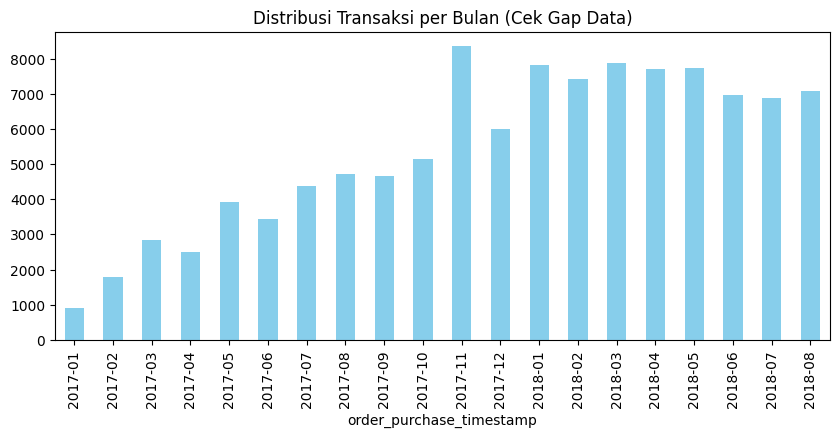

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# A. Cek Rentang Waktu (Temporal Coverage)
tgl_min = cleaning_df_olist_3['order_purchase_timestamp'].min()
tgl_max = cleaning_df_olist_3['order_purchase_timestamp'].max()
print(f"1. Rentang Waktu: {tgl_min} s/d {tgl_max}")
print(f"   Total Hari   : {(tgl_max - tgl_min).days} Hari")

# B. Cek Kelengkapan Provinsi (Geographical Coverage)
jml_provinsi = cleaning_df_olist_3['customer_state'].nunique()
print(f"2. Jumlah Provinsi: {jml_provinsi} (Target: 27)")
if jml_provinsi == 27:
    print("   Semua provinsi Brazil terwakili.")

# C. Cek Proporsi Hari Libur (Event Coverage)
cek_libur = cleaning_df_olist_3['holiday_name'].value_counts(normalize=True) * 100
print(f"3. Persentase Transaksi saat Libur: {cek_libur.get('Normal Day', 0):.2f}% Normal, {100 - cek_libur.get('Normal Day', 0):.2f}% Libur")

plt.figure(figsize=(10, 4))
cleaning_df_olist_3['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribusi Transaksi per Bulan (Cek Gap Data)')
plt.show()

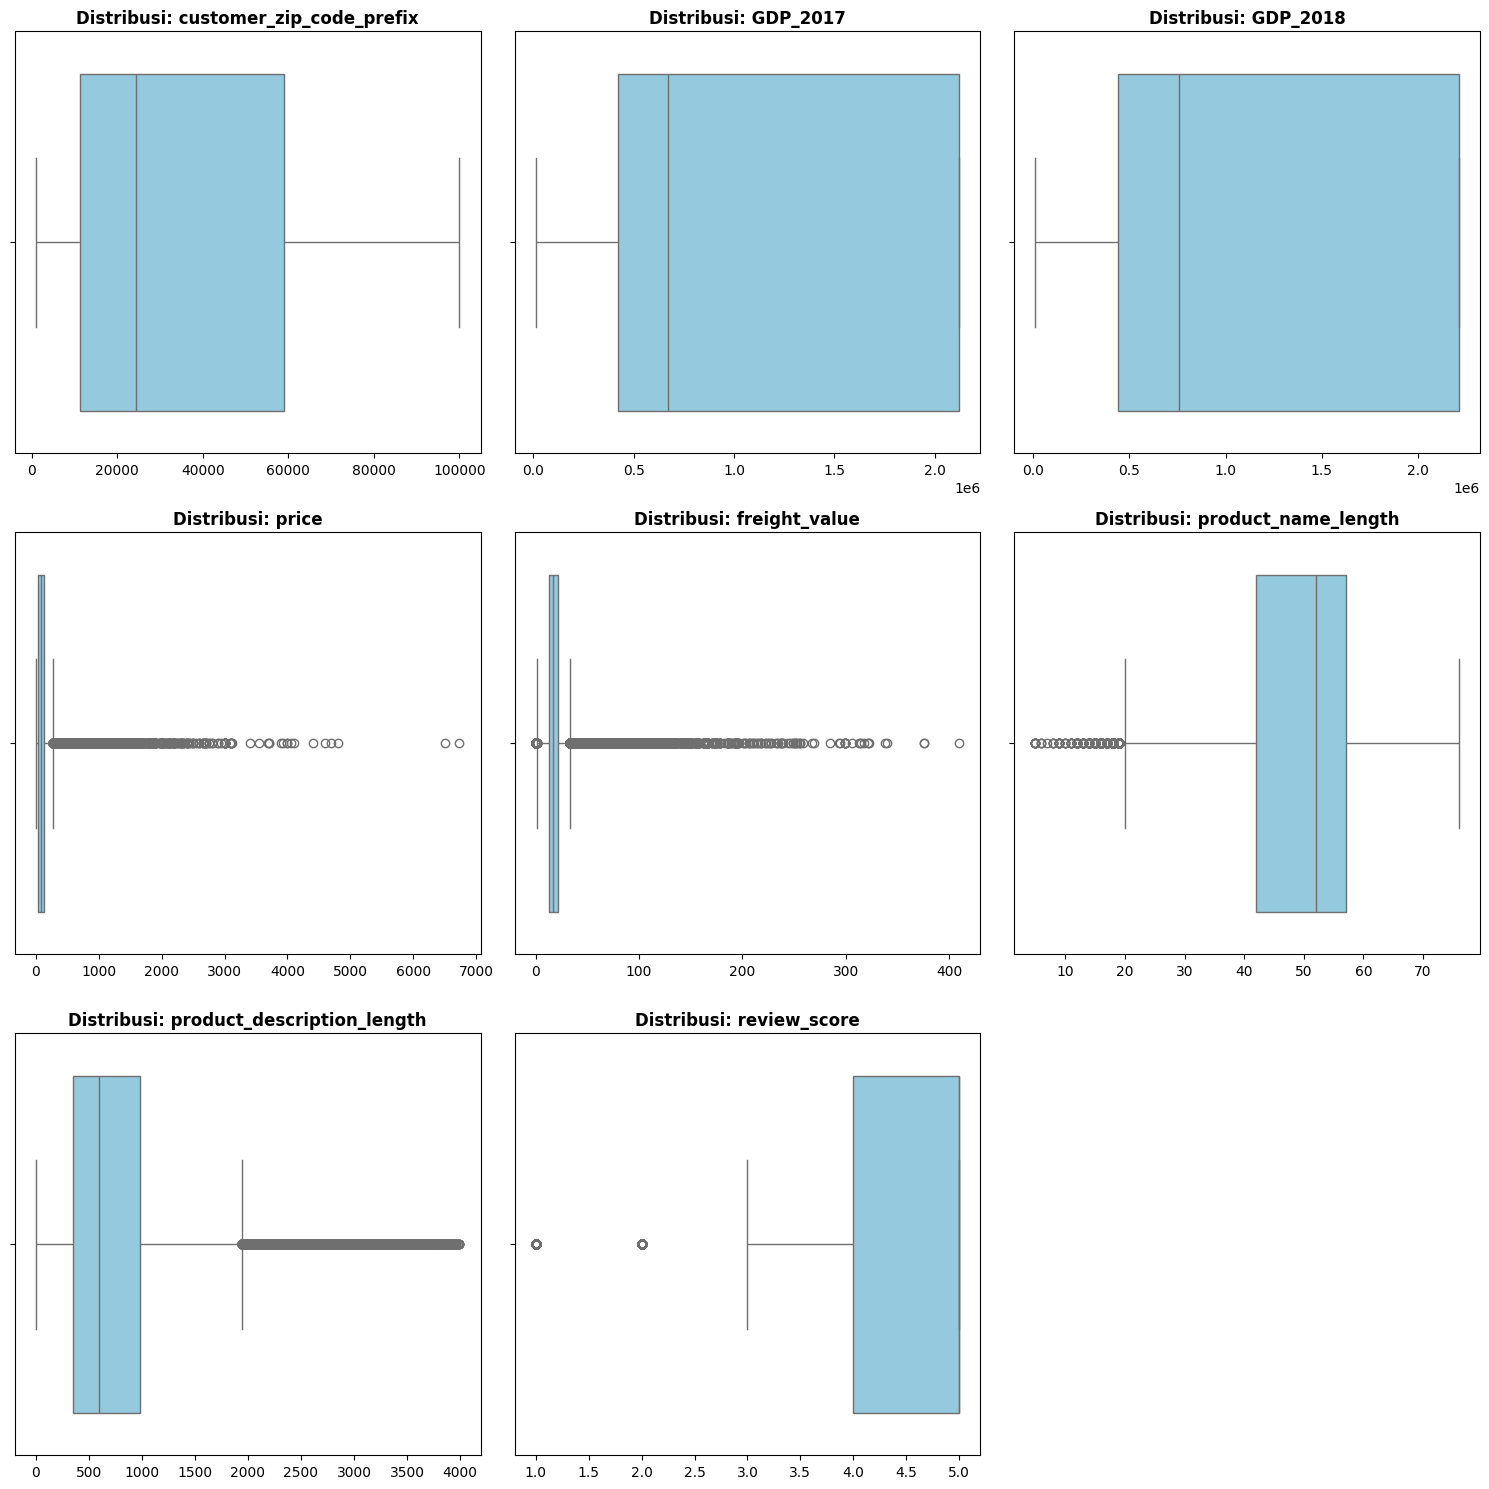

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

numeric_cols = cleaning_df_olist_3.select_dtypes(include=['float64', 'int64']).columns.tolist()

cols_to_skip = ['order_id', 'customer_id', 'customer_unique_id']
plot_cols = [c for c in numeric_cols if c not in cols_to_skip]

num_plots = len(plot_cols)
num_cols_grid = 3
num_rows_grid = math.ceil(num_plots / num_cols_grid)

fig, axes = plt.subplots(num_rows_grid, num_cols_grid, figsize=(15, 5 * num_rows_grid))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.boxplot(x=cleaning_df_olist_3[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribusi: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

cleaning_df_olist_4 = cleaning_df_olist_3

cleaning_df_olist_4['transaction_year'] = cleaning_df_olist_4['order_purchase_timestamp'].dt.year

cleaning_df_olist_4['GDP_Actual'] = np.where(
    cleaning_df_olist_4['transaction_year'] == 2017,
    cleaning_df_olist_4['GDP_2017'],
    cleaning_df_olist_4['GDP_2018']
)

cols_check = ['order_purchase_timestamp', 'GDP_2017', 'GDP_2018', 'GDP_Actual']
print(cleaning_df_olist_4[cols_check].sample(10))

col_gdp_actual = cleaning_df_olist_4.pop('GDP_Actual')

loc_2018 = cleaning_df_olist_4.columns.get_loc('GDP_2018')

cleaning_df_olist_4.insert(loc_2018 + 1, 'GDP_Actual', col_gdp_actual)



      order_purchase_timestamp      GDP_2017      GDP_2018    GDP_Actual
42146      2017-11-29 13:53:37  4.214979e+05  4.400294e+05  4.214979e+05
40512      2017-11-25 18:19:03  1.133999e+05  1.370201e+05  1.133999e+05
46676      2017-12-17 22:23:23  2.120762e+06  2.210562e+06  2.120762e+06
23867      2017-08-28 16:19:43  4.214979e+05  4.400294e+05  4.214979e+05
21529      2017-08-12 15:42:33  6.716057e+05  7.588590e+05  6.716057e+05
3444       2017-03-09 17:35:46  2.120762e+06  2.210562e+06  2.120762e+06
44891      2017-12-09 13:30:47  2.120762e+06  2.210562e+06  2.120762e+06
98876      2018-07-23 23:59:54  2.772702e+05  2.982271e+05  2.982271e+05
41358      2017-11-27 16:19:52  5.763755e+05  6.148758e+05  5.763755e+05
64835      2018-03-04 16:30:29  5.763755e+05  6.148758e+05  6.148758e+05


In [ ]:
cleaning_df_olist_4.head()

,order_id,customer_id,order_status,holiday_name,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,...,seller_id,price,freight_value,product_name_length,product_description_length,product_category_name_english,review_score,review_comment_title,review_comment_message,transaction_year
0,ec7a019261fce44180373d45b442d78f,c24fc5f9a446b4d8262041b9c64de772,delivered,Normal Day,2017-01-05 11:56:06,2017-01-11 13:14:05,2017-02-01 00:00:00,f7b981e8a280e455ac3cbe0d5d171bd1,80030,curitiba,...,48efc9d94a9834137efd9ea76b065a38,10.9,8.72,64.0,1710.0,fashion_bags_accessories,5,No Title,Adorei o produto! Super recomendo o lojista. R...,2017
1,b95a0a8bd30aece4e94e81f0591249d8,ff3c6d35b4927c9b965aa6a68dcf56e4,delivered,Normal Day,2017-01-05 12:01:20,2017-01-17 15:38:58,2017-02-13 00:00:00,83e7958a94bd7f74a9414d8782f87628,80030,curitiba,...,48efc9d94a9834137efd9ea76b065a38,10.9,8.72,52.0,1367.0,auto,5,No Title,"Adorei o produto, condiz com as imagens, a ent...",2017
2,38bcb524e1c38c2c1b60600a80fc8999,d2c63ad286e3ca9dd69218008d61ff81,delivered,Normal Day,2017-01-05 12:06:36,2017-01-16 16:05:22,2017-02-13 00:00:00,728e4a7d0db4845270091ded0923c71f,80540,curitiba,...,48efc9d94a9834137efd9ea76b065a38,2.9,8.72,48.0,1392.0,pet_shop,5,No Title,Loja entregou no prazo sem qualquer problema. ...,2017
3,7a18a504c1a4b32d883e68de2e1a7db0,e6bee29442c761ff0dfb9a4414922a5c,delivered,Normal Day,2017-01-05 12:09:08,2017-01-16 15:43:29,2017-02-13 00:00:00,728e4a7d0db4845270091ded0923c71f,80540,curitiba,...,48efc9d94a9834137efd9ea76b065a38,7.9,8.72,63.0,1269.0,pet_shop,5,No Title,Adorei a embalagem e o atendimento. Produto ma...,2017
4,6acecf438369055d9243e121045cca74,42d857e22f61f10476f0cda1aacc018a,delivered,Normal Day,2017-01-05 12:11:23,2017-01-17 16:06:30,2017-02-13 00:00:00,728e4a7d0db4845270091ded0923c71f,80540,curitiba,...,48efc9d94a9834137efd9ea76b065a38,9.9,8.72,54.0,282.0,pet_shop,5,No Title,"adorei o produto, a embalagem, o cuidado no en...",2017


In [ ]:
not_used_columns_2 = ['GDP_2017','GDP_2018']
cleaning_df_olist_5 = cleaning_df_olist_4.drop(columns=not_used_columns_2, errors='ignore')
cleaning_df_olist_5.head()

,order_id,customer_id,order_status,holiday_name,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,...,seller_id,price,freight_value,product_name_length,product_description_length,product_category_name_english,review_score,review_comment_title,review_comment_message,transaction_year
0,ec7a019261fce44180373d45b442d78f,c24fc5f9a446b4d8262041b9c64de772,delivered,Normal Day,2017-01-05 11:56:06,2017-01-11 13:14:05,2017-02-01 00:00:00,f7b981e8a280e455ac3cbe0d5d171bd1,80030,curitiba,...,48efc9d94a9834137efd9ea76b065a38,10.9,8.72,64.0,1710.0,fashion_bags_accessories,5,No Title,Adorei o produto! Super recomendo o lojista. R...,2017
1,b95a0a8bd30aece4e94e81f0591249d8,ff3c6d35b4927c9b965aa6a68dcf56e4,delivered,Normal Day,2017-01-05 12:01:20,2017-01-17 15:38:58,2017-02-13 00:00:00,83e7958a94bd7f74a9414d8782f87628,80030,curitiba,...,48efc9d94a9834137efd9ea76b065a38,10.9,8.72,52.0,1367.0,auto,5,No Title,"Adorei o produto, condiz com as imagens, a ent...",2017
2,38bcb524e1c38c2c1b60600a80fc8999,d2c63ad286e3ca9dd69218008d61ff81,delivered,Normal Day,2017-01-05 12:06:36,2017-01-16 16:05:22,2017-02-13 00:00:00,728e4a7d0db4845270091ded0923c71f,80540,curitiba,...,48efc9d94a9834137efd9ea76b065a38,2.9,8.72,48.0,1392.0,pet_shop,5,No Title,Loja entregou no prazo sem qualquer problema. ...,2017
3,7a18a504c1a4b32d883e68de2e1a7db0,e6bee29442c761ff0dfb9a4414922a5c,delivered,Normal Day,2017-01-05 12:09:08,2017-01-16 15:43:29,2017-02-13 00:00:00,728e4a7d0db4845270091ded0923c71f,80540,curitiba,...,48efc9d94a9834137efd9ea76b065a38,7.9,8.72,63.0,1269.0,pet_shop,5,No Title,Adorei a embalagem e o atendimento. Produto ma...,2017
4,6acecf438369055d9243e121045cca74,42d857e22f61f10476f0cda1aacc018a,delivered,Normal Day,2017-01-05 12:11:23,2017-01-17 16:06:30,2017-02-13 00:00:00,728e4a7d0db4845270091ded0923c71f,80540,curitiba,...,48efc9d94a9834137efd9ea76b065a38,9.9,8.72,54.0,282.0,pet_shop,5,No Title,"adorei o produto, a embalagem, o cuidado no en...",2017


In [ ]:
cleaning_df_olist_6 = cleaning_df_olist_5

cleaning_df_olist_6['transaction_year'] = pd.to_datetime(cleaning_df_olist_6['order_purchase_timestamp']).dt.year

cleaning_df_olist_6['Kuartil_GDP_Actual'] = np.where(
    cleaning_df_olist_6['transaction_year'] == 2017,
    cleaning_df_olist_6['Kuartil_GDP_2017'],
    cleaning_df_olist_6['Kuartil_GDP_2018']
)

cols = list(cleaning_df_olist_6.columns)
cols.remove('Kuartil_GDP_Actual')

idx_gdp = cols.index('GDP_Actual')
cols.insert(idx_gdp + 1, 'Kuartil_GDP_Actual')

cleaning_df_olist_6 = cleaning_df_olist_6[cols]

cleaning_df_olist_6.drop(columns=['Kuartil_GDP_2017', 'Kuartil_GDP_2018'], inplace=True)

cleaning_df_olist_6.head()

/tmp/ipython-input-2261174002.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaning_df_olist_6.drop(columns=['Kuartil_GDP_2017', 'Kuartil_GDP_2018'], inplace=True)


,order_id,customer_id,order_status,holiday_name,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,...,seller_id,price,freight_value,product_name_length,product_description_length,product_category_name_english,review_score,review_comment_title,review_comment_message,transaction_year
0,ec7a019261fce44180373d45b442d78f,c24fc5f9a446b4d8262041b9c64de772,delivered,Normal Day,2017-01-05 11:56:06,2017-01-11 13:14:05,2017-02-01 00:00:00,f7b981e8a280e455ac3cbe0d5d171bd1,80030,curitiba,...,48efc9d94a9834137efd9ea76b065a38,10.9,8.72,64.0,1710.0,fashion_bags_accessories,5,No Title,Adorei o produto! Super recomendo o lojista. R...,2017
1,b95a0a8bd30aece4e94e81f0591249d8,ff3c6d35b4927c9b965aa6a68dcf56e4,delivered,Normal Day,2017-01-05 12:01:20,2017-01-17 15:38:58,2017-02-13 00:00:00,83e7958a94bd7f74a9414d8782f87628,80030,curitiba,...,48efc9d94a9834137efd9ea76b065a38,10.9,8.72,52.0,1367.0,auto,5,No Title,"Adorei o produto, condiz com as imagens, a ent...",2017
2,38bcb524e1c38c2c1b60600a80fc8999,d2c63ad286e3ca9dd69218008d61ff81,delivered,Normal Day,2017-01-05 12:06:36,2017-01-16 16:05:22,2017-02-13 00:00:00,728e4a7d0db4845270091ded0923c71f,80540,curitiba,...,48efc9d94a9834137efd9ea76b065a38,2.9,8.72,48.0,1392.0,pet_shop,5,No Title,Loja entregou no prazo sem qualquer problema. ...,2017
3,7a18a504c1a4b32d883e68de2e1a7db0,e6bee29442c761ff0dfb9a4414922a5c,delivered,Normal Day,2017-01-05 12:09:08,2017-01-16 15:43:29,2017-02-13 00:00:00,728e4a7d0db4845270091ded0923c71f,80540,curitiba,...,48efc9d94a9834137efd9ea76b065a38,7.9,8.72,63.0,1269.0,pet_shop,5,No Title,Adorei a embalagem e o atendimento. Produto ma...,2017
4,6acecf438369055d9243e121045cca74,42d857e22f61f10476f0cda1aacc018a,delivered,Normal Day,2017-01-05 12:11:23,2017-01-17 16:06:30,2017-02-13 00:00:00,728e4a7d0db4845270091ded0923c71f,80540,curitiba,...,48efc9d94a9834137efd9ea76b065a38,9.9,8.72,54.0,282.0,pet_shop,5,No Title,"adorei o produto, a embalagem, o cuidado no en...",2017


In [ ]:
import pandas as pd
import numpy as np

cleaning_df_olist_6 = cleaning_df_olist_5

# A. PERSIAPAN STORY 2 (Patience & Satisfaction)
cols_date = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in cols_date:
    cleaning_df_olist_6[col] = pd.to_datetime(cleaning_df_olist_6[col], errors='coerce')

# 1. Hitung Lama Pengiriman (Hari)
cleaning_df_olist_6['delivery_days'] = (cleaning_df_olist_6['order_delivered_customer_date'] - cleaning_df_olist_6['order_purchase_timestamp']).dt.days

# 2. Hitung Keterlambatan (Hari)
# Jika positif = Telat, Jika negatif = Lebih cepat dari estimasi
cleaning_df_olist_6['delay_days'] = (cleaning_df_olist_6['order_delivered_customer_date'] - cleaning_df_olist_6['order_estimated_delivery_date']).dt.days


# B. PERSIAPAN STORY 3 (Seasonal Spender)
# 3. Ubah Holiday jadi Angka (1 = Libur, 0 = Normal)
cleaning_df_olist_6['is_holiday'] = np.where(cleaning_df_olist_6['holiday_name'] == 'Normal Day', 0, 1)

print("✅ Variabel baru siap: delivery_days, delay_days, is_holiday")

✅ Variabel baru siap: delivery_days, delay_days, is_holiday


In [ ]:
cleaning_df_olist_6[['GDP_Actual', 'price', 'freight_value']].corr()

,GDP_Actual,price,freight_value
GDP_Actual,1.000000,-0.055709,-0.289846
price,-0.055709,1.000000,0.411157
freight_value,-0.289846,0.411157,1.000000


In [ ]:
cleaning_df_olist_6[['review_score', 'delivery_days', 'delay_days']].corr()

,review_score,delivery_days,delay_days
review_score,1.000000,-0.305356,-0.232051
delivery_days,-0.305356,1.000000,0.599085
delay_days,-0.232051,0.599085,1.000000


In [ ]:
df_seasonality_check = cleaning_df_olist_6.copy()
seasonality_check = df_seasonality_check.groupby('holiday_name')['price'].agg(['mean', 'median', 'count'])

print(seasonality_check)

                                    mean  median   count
holiday_name                                            
All Souls' Day                149.467589  84.900     141
Christmas Day                 102.964421  72.900      95
Good Friday                   121.683537  65.900     229
Independence Day              161.712059  82.495     102
Normal Day                    119.790450  74.900  106485
Our Lady of Aparecida         119.911208  87.000     149
Republic Proclamation Day     109.162621  68.945     206
Tiradentes' Day               110.054748  73.900     238
Universal Fraternization Day   85.313247  72.000      77
Worker's Day                  109.850352  69.900     398


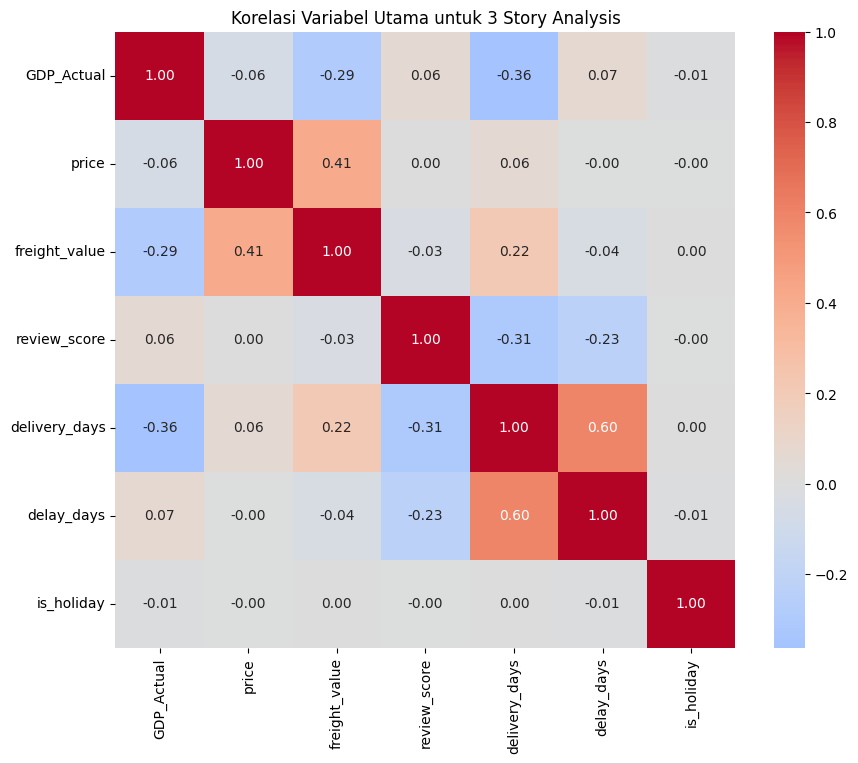

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pilih kolom-kolom "Daging" untuk 3 Story tadi
cols_analysis = [
    # Story 1: Economy
    'GDP_Actual', 'price', 'freight_value',
    # Story 2: Satisfaction
    'review_score', 'delivery_days', 'delay_days',
    # Story 3: Seasonality
    'is_holiday'
]

# Hitung Korelasi
corr_matrix = cleaning_df_olist_6[cols_analysis].corr()

# Visualisasi Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Korelasi Variabel Utama untuk 3 Story Analysis')
plt.show()

In [ ]:
cleaning_df_olist_6.describe()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,GDP_Actual,price,freight_value,product_name_length,product_description_length,review_score,transaction_year,delivery_days,delay_days,is_holiday
count,108120,108120,108120,108120.000000,1.081200e+05,108120.000000,108120.000000,108120.000000,108120.000000,108120.000000,108120.000000,108120.000000,108120.000000,108120.000000
mean,2018-01-03 23:19:43.541657344,2018-01-16 09:09:44.158573568,2018-01-27 16:34:57.669256448,35141.214900,1.168667e+06,119.755269,19.969037,48.809212,786.244136,4.083925,2017.550222,11.945098,-12.006761,0.015122
min,2017-01-05 11:56:06,2017-01-11 13:14:05,2017-02-01 00:00:00,1003.000000,1.210471e+04,0.850000,0.000000,5.000000,4.000000,1.000000,2017.000000,0.000000,-147.000000,0.000000
25%,2017-09-17 15:11:23,2017-09-28 19:19:10,2017-10-09 00:00:00,11250.000000,4.232700e+05,39.900000,13.080000,42.000000,348.000000,4.000000,2017.000000,6.000000,-17.000000,0.000000
50%,2018-01-22 16:44:38.500000,2018-02-05 18:38:08,2018-02-19 00:00:00,24330.000000,6.716057e+05,74.900000,16.280000,52.000000,601.000000,5.000000,2018.000000,10.000000,-13.000000,0.000000
75%,2018-05-06 19:13:32.249999872,2018-05-16 16:18:44.249999872,2018-05-28 00:00:00,59063.000000,2.120762e+06,134.000000,21.150000,57.000000,985.000000,5.000000,2018.000000,15.000000,-7.000000,0.000000
max,2018-08-29 15:00:37,2018-10-17 13:22:46,2018-10-25 00:00:00,99980.000000,2.210562e+06,6735.000000,409.680000,76.000000,3992.000000,5.000000,2018.000000,208.000000,188.000000,1.000000
std,NaN,NaN,NaN,29909.005791,8.759411e+05,180.456985,15.707723,10.002533,650.800197,1.345153,0.497474,9.334156,9.984667,0.122039


## 2. Understand Data Structures

In [ ]:
# A. Dimensi Data
print(f"1. Bentuk Data (Shape): {cleaning_df_olist_6.shape[0]} Baris, {cleaning_df_olist_6.shape[1]} Kolom")

# B. Tipe Data
print("\n2. Pengecekan Tipe Data:")
print(cleaning_df_olist_6.dtypes)

# C. Cek Primary Key (Apakah Order ID Unik?)
jml_order_unik = cleaning_df_olist_6['order_id'].nunique()
jml_baris = len(cleaning_df_olist_6)
print(f"\n3. Integritas Data:")
print(f"Jumlah Order ID Unik: {jml_order_unik}")
print(f"Jumlah Baris Total  : {jml_baris}")
if jml_order_unik == jml_baris:
    print("Satu baris = Satu transaksi (Unik)")
else:
    print("Ada Order ID yang berulang (Wajar jika satu order beli banyak barang)")

1. Bentuk Data (Shape): 108120 Baris, 29 Kolom

2. Pengecekan Tipe Data:
order_id                                 object
customer_id                              object
order_status                             object
holiday_name                             object
order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
Kuartil_GDP_2017                         object
GDP_Actual                              float64
Kuartil_GDP_2018                         object
product_id                               object
seller_id                                object
price                                   float64
freight_value                           float64
product_name_length                     float64
product_descrip



## 3. Identify Potential Issues


=== [3] IDENTIFY POTENTIAL ISSUES (MASALAH) ===
1. Sisa Missing Values:
Series([], dtype: int64)

2. Statistik Anomali (Harga & Ongkir):
               price  freight_value
count  108120.000000  108120.000000
mean      119.755269      19.969037
std       180.456985      15.707723
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.900000      16.280000
75%       134.000000      21.150000
max      6735.000000     409.680000

3. Deteksi Outlier (Visual):


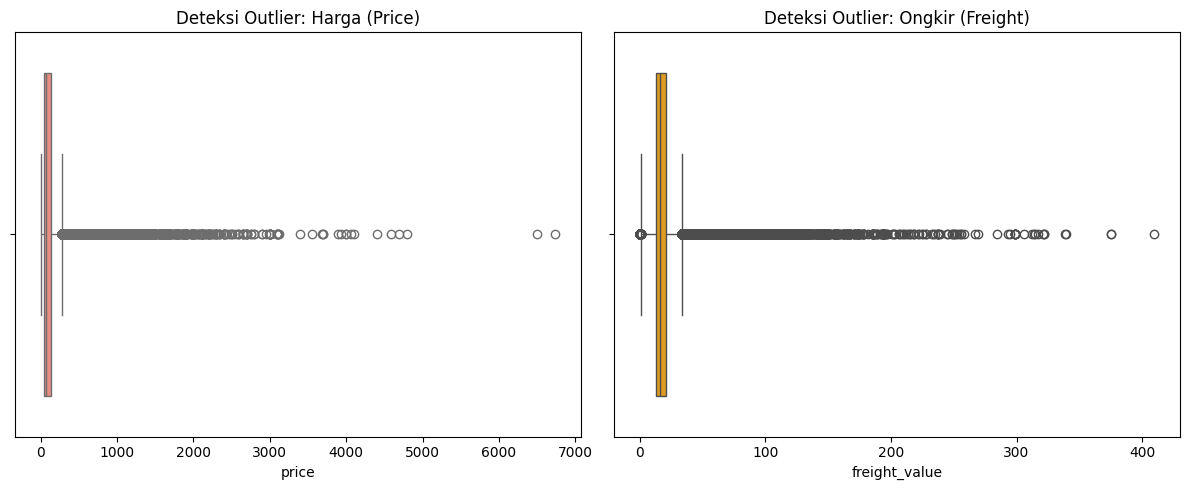

In [ ]:
print("\n=== [3] IDENTIFY POTENTIAL ISSUES (MASALAH) ===")

# A. Cek Missing Values
print("1. Sisa Missing Values:")
nan_check = cleaning_df_olist_6.isnull().sum()
print(nan_check[nan_check > 0]) # Tampilkan cuma yang error

# B. Statistik Deskriptif
print("\n2. Statistik Anomali (Harga & Ongkir):")
print(cleaning_df_olist_6[['price', 'freight_value']].describe())

# C. Visualisasi Outlier (Boxplot)
print("\n3. Deteksi Outlier (Visual):")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot Harga
sns.boxplot(x=cleaning_df_olist_6['price'], ax=axes[0], color='salmon')
axes[0].set_title('Deteksi Outlier: Harga (Price)')

# Boxplot Ongkir
sns.boxplot(x=cleaning_df_olist_6['freight_value'], ax=axes[1], color='orange')
axes[1].set_title('Deteksi Outlier: Ongkir (Freight)')

plt.tight_layout()
plt.show()

In [ ]:
df_olist_integrated_clean = cleaning_df_olist_6

# b. 2. Revisi Tambahan Data Cleaning

Membuang kolom 'order_status' karena semua data memiliki order status = delivered dan tidak membuang 'review_comment_message' karena masih bisa digunakan untuk analisis lanjutan.

In [ ]:
not_used_columns_2 = [
    'order_status'
]

df_olist_integrated_clean = df_olist_integrated_clean.drop(columns=not_used_columns_2, errors='ignore')

print(f"Jumlah kolom sebelum: {cleaning_df_olist_6.shape[1]}")
print(f"Jumlah kolom sesudah: {df_olist_integrated_clean.shape[1]}")
df_olist_integrated_clean



Jumlah kolom sebelum: 29
Jumlah kolom sesudah: 28


,order_id,customer_id,holiday_name,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,Kuartil_GDP_2017,GDP_Actual,Kuartil_GDP_2018,product_id,seller_id,price,freight_value,product_name_length,product_description_length,product_category_name_english,review_score,review_comment_title,review_comment_message,transaction_year,Kuartil_GDP_Actual,delivery_days,delay_days,is_holiday
0,ec7a019261fce44180373d45b442d78f,c24fc5f9a446b4d8262041b9c64de772,Normal Day,2017-01-05 11:56:06,2017-01-11 13:14:05,2017-02-01,f7b981e8a280e455ac3cbe0d5d171bd1,80030,curitiba,PR,High,4.214979e+05,High,f5d8f4fbc70ca2a0038b9a0010ed5cb0,48efc9d94a9834137efd9ea76b065a38,10.90,8.72,64.0,1710.0,fashion_bags_accessories,5,No Title,Adorei o produto! Super recomendo o lojista. R...,2017,High,6,-21,0
1,b95a0a8bd30aece4e94e81f0591249d8,ff3c6d35b4927c9b965aa6a68dcf56e4,Normal Day,2017-01-05 12:01:20,2017-01-17 15:38:58,2017-02-13,83e7958a94bd7f74a9414d8782f87628,80030,curitiba,PR,High,4.214979e+05,High,6c04a068e5ab37749c980c42a036b9e3,48efc9d94a9834137efd9ea76b065a38,10.90,8.72,52.0,1367.0,auto,5,No Title,"Adorei o produto, condiz com as imagens, a ent...",2017,High,12,-27,0
2,38bcb524e1c38c2c1b60600a80fc8999,d2c63ad286e3ca9dd69218008d61ff81,Normal Day,2017-01-05 12:06:36,2017-01-16 16:05:22,2017-02-13,728e4a7d0db4845270091ded0923c71f,80540,curitiba,PR,High,4.214979e+05,High,680cc8535be7cc69544238c1d6a83fe8,48efc9d94a9834137efd9ea76b065a38,2.90,8.72,48.0,1392.0,pet_shop,5,No Title,Loja entregou no prazo sem qualquer problema. ...,2017,High,11,-28,0
3,7a18a504c1a4b32d883e68de2e1a7db0,e6bee29442c761ff0dfb9a4414922a5c,Normal Day,2017-01-05 12:09:08,2017-01-16 15:43:29,2017-02-13,728e4a7d0db4845270091ded0923c71f,80540,curitiba,PR,High,4.214979e+05,High,c0d4027067afcf9c1697cce981b8fed6,48efc9d94a9834137efd9ea76b065a38,7.90,8.72,63.0,1269.0,pet_shop,5,No Title,Adorei a embalagem e o atendimento. Produto ma...,2017,High,11,-28,0
4,6acecf438369055d9243e121045cca74,42d857e22f61f10476f0cda1aacc018a,Normal Day,2017-01-05 12:11:23,2017-01-17 16:06:30,2017-02-13,728e4a7d0db4845270091ded0923c71f,80540,curitiba,PR,High,4.214979e+05,High,1514ddb0f4a5afc8d24104e89c714403,48efc9d94a9834137efd9ea76b065a38,9.90,8.72,54.0,282.0,pet_shop,5,No Title,"adorei o produto, a embalagem, o cuidado no en...",2017,High,12,-27,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108115,0b223d92c27432930dfe407c6aea3041,e60df9449653a95af4549bbfcb18a6eb,Normal Day,2018-08-29 14:18:23,2018-08-30 16:24:55,2018-09-04,5c58de6fb80e93396e2f35642666b693,80045,curitiba,PR,High,4.400294e+05,High,2b4472df15512a2825ae86fd9ae79335,67bf6941ba2f1fa1d02c375766bc3e53,209.00,46.48,44.0,112.0,kitchen_dining_laundry_garden_furniture,5,No Title,No Comment,2018,High,1,-5,0
108116,0b223d92c27432930dfe407c6aea3041,e60df9449653a95af4549bbfcb18a6eb,Normal Day,2018-08-29 14:18:23,2018-08-30 16:24:55,2018-09-04,5c58de6fb80e93396e2f35642666b693,80045,curitiba,PR,High,4.400294e+05,High,2b4472df15512a2825ae86fd9ae79335,67bf6941ba2f1fa1d02c375766bc3e53,209.00,46.48,44.0,112.0,kitchen_dining_laundry_garden_furniture,5,No Title,No Comment,2018,High,1,-5,0
108117,168626408cb32af0ffaf76711caae1dc,6e353700bc7bcdf6ebc15d6de16d7002,Normal Day,2018-08-29 14:18:28,2018-08-30 16:52:31,2018-09-11,7febafa06d9d8f232a900a2937f04338,38600,paracatu,MG,High,6.148758e+05,High,bdcf6a834e8faa30dac3886c7a58e92e,2a84855fd20af891be03bc5924d2b453,45.90,15.39,26.0,394.0,health_beauty,5,Chegou rápido e correto,Recomendo,2018,High,1,-12,0
108118,03ef5dedbe7492bdae72eec50764c43f,496630b6740bcca28fce9ba50d8a26ef,Normal Day,2018-08-29 14:52:00,2018-08-30 16:36:59,2018-09-03,b701bebbdf478f5500348f03aff62121,9541,sao caetano do sul,SP,High,2.210562e+06,High,c7f27c5bef2338541c772b5776403e6a,7d7866a99a8656a42c7ff6352a433410,24.90,8.33,54.0,429.0,party_supplies,3,Recomendo,No Comment,2018,High,1,

# d. Data publishing (raw data, hasil proses wrangling, dan dokumentasi)

Dihapus untuk keamanan

## 3. , Dokumentasi Pipeline

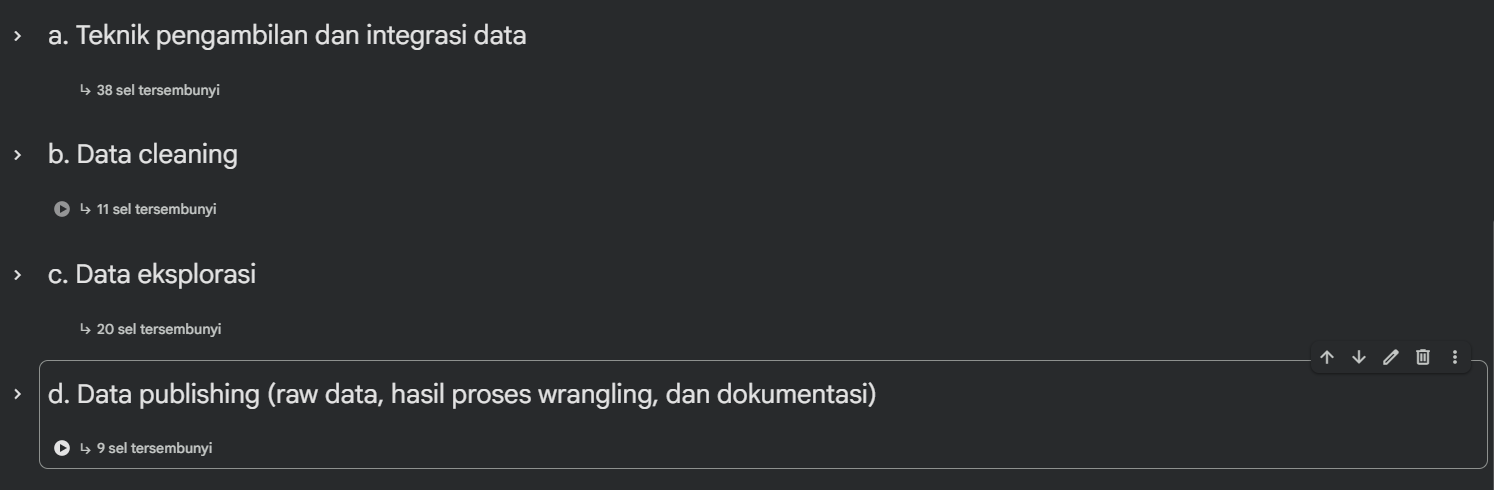